# Flow Matching on Real Berkeley UR5 Demonstrations

This notebook loads the numeric portion of the Berkeley Autolab UR5 dataset, visualizes recorded trajectories, trains a small conditional rectified-flow model, and samples new state trajectories. The model is conditioned on the recorded start state, goal state, and task ID.

> The converted dataset describes the eight state channels only as `motor_0` … `motor_7`. Their ranges most likely represent end-effector `XYZ + quaternion + gripper`, so the 3D section uses that configurable assumption and inverse kinematics. The flow model still retains all eight channels. This baseline does not use obstacle maps or camera video.

## 1. Setup

In [88]:
# Run once if these packages are missing in the active notebook kernel.
%pip install -q numpy pandas pyarrow matplotlib plotly scipy tqdm torch

Note: you may need to restart the kernel to use updated packages.


In [89]:
from pathlib import Path
import json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
from tqdm.auto import tqdm

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Code' else Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'Data' / 'berkeley_ur5'
RESULTS_DIR = PROJECT_ROOT / 'Results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename, dpi=180):
    path = RESULTS_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved:', path)
    return path

# Editable state interpretation used by the 3D visualization in Section 7.
# The value ranges strongly suggest: Cartesian XYZ [m], quaternion, gripper [0, 1].
# This is an informed assumption—not an authoritative joint-state definition.
POSITION_CHANNELS = (0, 1, 2)
QUATERNION_CHANNELS = (3, 4, 5, 6)
QUATERNION_ORDER = 'xyzw'       # Change to 'wxyz' if later metadata confirms that order.
GRIPPER_CHANNEL = 7
ANIMATION_GENERATED_SAMPLE = 0  # Which blue generated trajectory to animate.
ANIMATION_FRAME_MS = 120
IK_POSITION_WEIGHT = 1.0
IK_ORIENTATION_WEIGHT = 0.20    # Metres per radian; lower if orientation is unreliable.
DATA_TO_UR5_BASE = np.eye(4)    # Edit if dataset and UR5 base frames differ.
print('project:', PROJECT_ROOT)
print('results:', RESULTS_DIR)
print('device:', DEVICE)

project: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation
results: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results
device: cuda


If the next cell reports that data is missing, run this in a terminal from the project root:

```bash
hf download lerobot/berkeley_autolab_ur5 --repo-type dataset \
  --include "data/*/*.parquet" --include "meta/*.json" \
  --local-dir Data/berkeley_ur5
```

## 2. Load and inspect the data

In [90]:
parquet_files = sorted(DATA_ROOT.glob('data/**/*.parquet'))
if not parquet_files:
    raise FileNotFoundError(f'No Parquet files below {DATA_ROOT}. Run the download command above.')

frames = pd.concat((pd.read_parquet(path) for path in parquet_files), ignore_index=True)
frames = frames.sort_values(['episode_index', 'frame_index']).reset_index(drop=True)
print(f'{len(frames):,} frames, {frames.episode_index.nunique():,} episodes')
print('columns:', list(frames.columns))
frames.head()

97,939 frames, 1,000 episodes
columns: ['observation.state', 'action', 'timestamp', 'episode_index', 'frame_index', 'next.reward', 'next.done', 'index', 'task_index']


,observation.state,action,timestamp,episode_index,frame_index,next.reward,next.done,index,task_index
0,"[0.36736205, 0.05681828, -0.014337844, 0.63365...","[-0.0022857143, 0.006857143, 0.0035428572, -0....",0.0,0,0,0.0,False,0,0
1,"[0.3713127, 0.05632875, -0.016050117, 0.633727...","[-0.009542857, 0.011485714, 0.005085714, -0.00...",0.2,0,1,0.0,False,1,0
2,"[0.37898293, 0.052731365, -0.018827463, 0.6367...","[-0.011085714, 0.010571429, 0.007657143, 0.0, ...",0.4,0,2,0.0,False,2,0
3,"[0.3873519, 0.047187503, -0.0229582, 0.6406953...","[-0.011714286, 0.009028572, 0.0089714285, 0.0,...",0.6,0,3,0.0,False,3,0
4,"[0.3946254, 0.04107245, -0.028223827, 0.645230...","[-0.014114286, 0.0089714285, 0.012742857, 0.0,...",0.8,0,4,0.0,False,4,0


In [91]:
info_path = DATA_ROOT / 'meta' / 'info.json'
if info_path.exists():
    info = json.loads(info_path.read_text())
    print({key: info.get(key) for key in ['total_episodes', 'total_frames', 'total_tasks', 'fps']})

first = frames.iloc[0]
print('state shape:', np.asarray(first['observation.state']).shape)
print('action shape:', np.asarray(first['action']).shape)
print('task IDs:', sorted(frames.task_index.unique().tolist()))
if 'language_instruction' in frames:
    display(frames[['task_index', 'language_instruction']].drop_duplicates().sort_values('task_index'))

{'total_episodes': 1000, 'total_frames': 97939, 'total_tasks': 5, 'fps': 5}
state shape: (8,)
action shape: (7,)
task IDs: [0, 1, 2, 3, 4]


## 3. Visualize recorded trajectories

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/01_recorded_trajectories.png


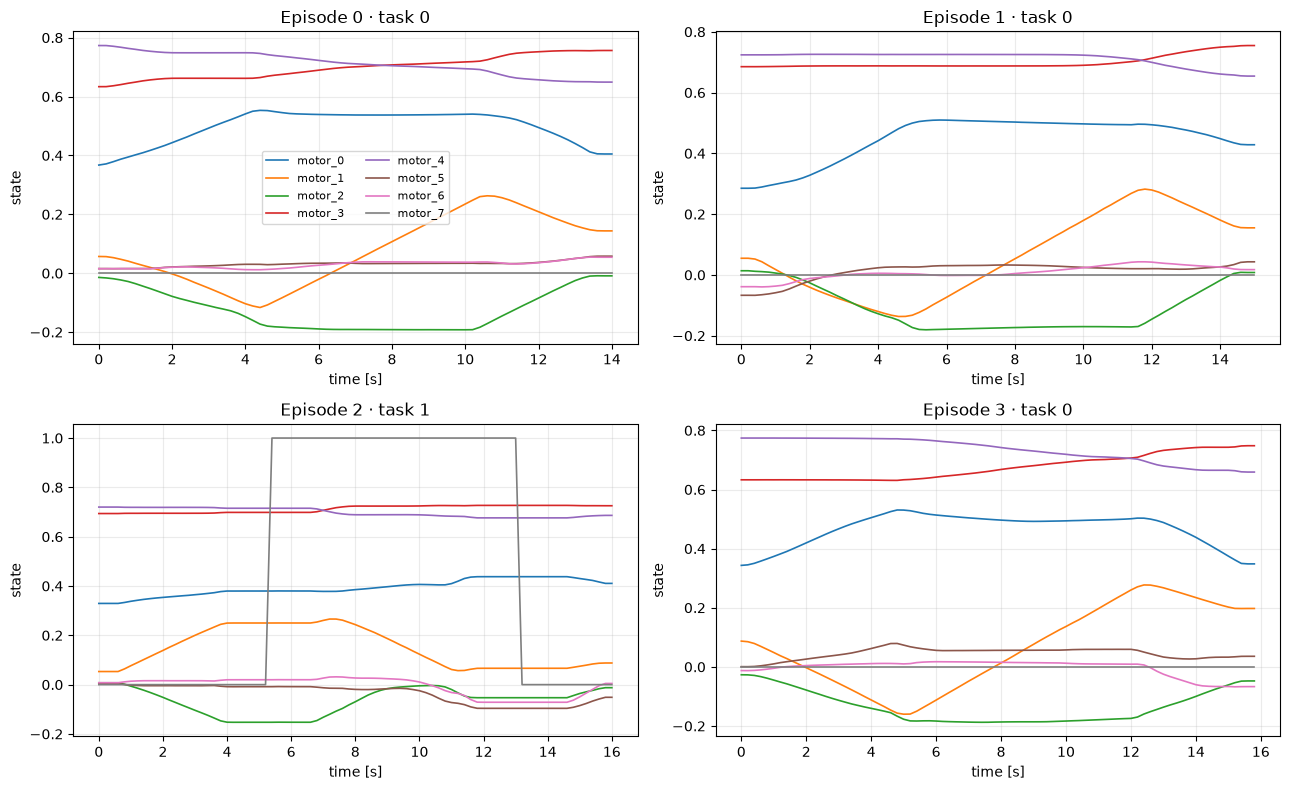

In [92]:
episode_ids = frames.episode_index.drop_duplicates().iloc[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
for ax, episode_id in zip(axes.flat, episode_ids):
    episode = frames[frames.episode_index == episode_id]
    states = np.stack(episode['observation.state'].map(np.asarray))
    time = episode['timestamp'].to_numpy()
    ax.plot(time, states, linewidth=1.2)
    ax.set(title=f'Episode {episode_id} · task {episode.task_index.iloc[0]}', xlabel='time [s]', ylabel='state')
    ax.grid(alpha=.25)
axes[0, 0].legend([f'motor_{i}' for i in range(states.shape[1])], ncol=2, fontsize=8)
fig.tight_layout(); save_figure(fig, '01_recorded_trajectories.png'); plt.show()

## 4. Build fixed-length trajectory examples

Episodes have different durations. We linearly resample each complete recorded episode to 32 points, normalize each state channel over the training collection, and represent task ID as a one-hot vector.

In [93]:
# Quality-oriented settings for this small (1,000 episode) dataset.
TRAJECTORY_STEPS = 32
BATCH_SIZE = 64
HIDDEN_DIM = 256  # temporal-convolution channels
EPOCHS = 500
LEARNING_RATE = 1e-4
ODE_STEPS = 200
NUM_TASKS = int(frames.task_index.max()) + 1

def resample_episode(values, steps=TRAJECTORY_STEPS):
    values = np.asarray(values, dtype=np.float32)
    old_t = np.linspace(0.0, 1.0, len(values))
    new_t = np.linspace(0.0, 1.0, steps)
    return np.stack([np.interp(new_t, old_t, values[:, j]) for j in range(values.shape[1])], axis=1)

trajectories, task_ids = [], []
for _, episode in tqdm(frames.groupby('episode_index'), desc='resampling'):
    state = np.stack(episode['observation.state'].map(np.asarray))
    if len(state) >= 2 and np.isfinite(state).all():
        trajectories.append(resample_episode(state))
        task_ids.append(int(episode.task_index.iloc[0]))

trajectories = np.stack(trajectories).astype(np.float32)
task_ids = np.asarray(task_ids)
state_mean = trajectories.reshape(-1, trajectories.shape[-1]).mean(0)
state_std = trajectories.reshape(-1, trajectories.shape[-1]).std(0).clip(1e-5)
normalized = (trajectories - state_mean[None, None]) / state_std[None, None]
tasks = np.eye(NUM_TASKS, dtype=np.float32)[task_ids]
print('trajectories:', trajectories.shape, 'tasks:', tasks.shape)

resampling: 100%|██████████| 1000/1000 [00:00<00:00, 6534.86it/s]

trajectories: (1000, 32, 8) tasks: (1000, 5)


## 5. Small conditional rectified-flow model

In [94]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim=32):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        frequency = torch.exp(torch.arange(half, device=t.device) * (-math.log(10000) / max(half-1, 1)))
        phase = t[:, None] * frequency[None]
        return torch.cat([phase.sin(), phase.cos()], dim=-1)

class ResidualConvBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv1d(channels, channels, 1),
        )
    def forward(self, x):
        return x + self.block(x)

class TemporalConvFlow(nn.Module):
    def __init__(self, state_dim, num_tasks, channels=256, dilations=(1, 2, 4, 8)):
        super().__init__()
        condition_dim = 32 + 2 * state_dim + num_tasks
        self.time = TimeEmbedding(32)
        self.condition = nn.Sequential(nn.Linear(condition_dim, channels), nn.SiLU())
        self.input = nn.Conv1d(state_dim, channels, 1)
        self.blocks = nn.Sequential(*[
            ResidualConvBlock(channels, dilation) for dilation in dilations
        ])
        self.output = nn.Sequential(
            nn.GroupNorm(8, channels), nn.SiLU(), nn.Conv1d(channels, state_dim, 1)
        )
    def forward(self, t, x, start, goal, task):
        condition = torch.cat([self.time(t), start, goal, task], dim=-1)
        condition = self.condition(condition)[:, :, None]
        hidden = self.input(x.transpose(1, 2)) + condition
        return self.output(self.blocks(hidden)).transpose(1, 2)

trajectory_tensor = torch.from_numpy(normalized)
task_tensor = torch.from_numpy(tasks)
dataset = TensorDataset(trajectory_tensor, task_tensor)
n_val = max(1, int(0.1 * len(dataset)))
train_data, val_data = random_split(dataset, [len(dataset)-n_val, n_val], generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=2 * BATCH_SIZE)
model = TemporalConvFlow(trajectories.shape[-1], NUM_TASKS, channels=HIDDEN_DIM).to(DEVICE)
sum(p.numel() for p in model.parameters())

1073416

The endpoints are fixed by generating only the 30 interior points. The training target is a residual around straight interpolation between the start and goal state.

In [95]:
def residual_target(trajectory):
    s = torch.linspace(0, 1, trajectory.shape[1], device=trajectory.device)[None, :, None]
    reference = (1-s) * trajectory[:, :1] + s * trajectory[:, -1:]
    return trajectory[:, 1:-1] - reference[:, 1:-1]

def flow_loss(model, trajectory, task):
    data = residual_target(trajectory)
    noise = torch.randn_like(data)
    t = torch.rand(len(data), device=data.device)
    x_t = (1-t[:, None, None]) * noise + t[:, None, None] * data
    target_velocity = data - noise
    prediction = model(t, x_t, trajectory[:, 0], trajectory[:, -1], task)
    return nn.functional.mse_loss(prediction, target_velocity)

## 6. Train

epoch 001 | train 1.43605 | val 1.17878
epoch 005 | train 0.64765 | val 0.64033
epoch 010 | train 0.53481 | val 0.54950
epoch 015 | train 0.50039 | val 0.52034
epoch 020 | train 0.45865 | val 0.47068
epoch 025 | train 0.44060 | val 0.47683
epoch 030 | train 0.41530 | val 0.41495
epoch 035 | train 0.39063 | val 0.45311
epoch 040 | train 0.40698 | val 0.45771
epoch 045 | train 0.37616 | val 0.40557
epoch 050 | train 0.38161 | val 0.37706
epoch 055 | train 0.36225 | val 0.37040
epoch 060 | train 0.35826 | val 0.35712
epoch 065 | train 0.33542 | val 0.41502
epoch 070 | train 0.32531 | val 0.36032
epoch 075 | train 0.31563 | val 0.37141
epoch 080 | train 0.32905 | val 0.39359
epoch 085 | train 0.30799 | val 0.33624
epoch 090 | train 0.32826 | val 0.32469
epoch 095 | train 0.31002 | val 0.35533
epoch 100 | train 0.30885 | val 0.31081
epoch 105 | train 0.30494 | val 0.36033
epoch 110 | train 0.30509 | val 0.35674
epoch 115 | train 0.30552 | val 0.29758
epoch 120 | train 0.29375 | val 0.39275


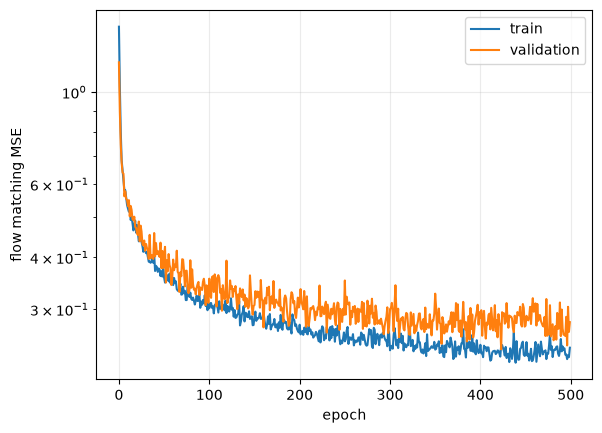

best checkpoint: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/runs/berkeley_ur5_temporal_conv_flow.pt


In [96]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
history = {'train': [], 'val': []}
best_val = float('inf')
checkpoint_path = PROJECT_ROOT / 'runs' / 'berkeley_ur5_temporal_conv_flow.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train(); train_losses = []
    for trajectory, task in train_loader:
        trajectory, task = trajectory.to(DEVICE), task.to(DEVICE)
        loss = flow_loss(model, trajectory, task)
        optimizer.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        train_losses.append(loss.item())
    model.eval(); val_losses = []
    with torch.no_grad():
        for trajectory, task in val_loader:
            val_losses.append(flow_loss(model, trajectory.to(DEVICE), task.to(DEVICE)).item())
    scheduler.step()
    train_loss, val_loss = np.mean(train_losses), np.mean(val_losses)
    history['train'].append(train_loss); history['val'].append(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        torch.save({'model': model.state_dict(), 'mean': state_mean, 'std': state_std,
                    'steps': TRAJECTORY_STEPS, 'num_tasks': NUM_TASKS}, checkpoint_path)
    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f}')

plt.plot(history['train'], label='train'); plt.plot(history['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('flow matching MSE'); plt.yscale('log'); plt.legend(); plt.grid(alpha=.25)
save_figure(plt.gcf(), '02_initial_flow_training.png'); plt.show()
print('best checkpoint:', checkpoint_path)

## 7. Generate, visualize, and evaluate trajectories

For one held-out validation episode, the model generates several trajectories from different random initial noises while keeping the same start state, goal state, and task ID. In every panel below:

- the **black dashed line** is the real recorded demonstration;
- the **blue solid lines** are independently generated trajectories;
- the horizontal axis is the resampled trajectory step, not wall-clock time;
- each panel shows one anonymous state channel from the Berkeley dataset.

The generated paths do not need to exactly reproduce the demonstration: multiple motions may be valid for the same condition.

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/03_initial_flow_samples.png


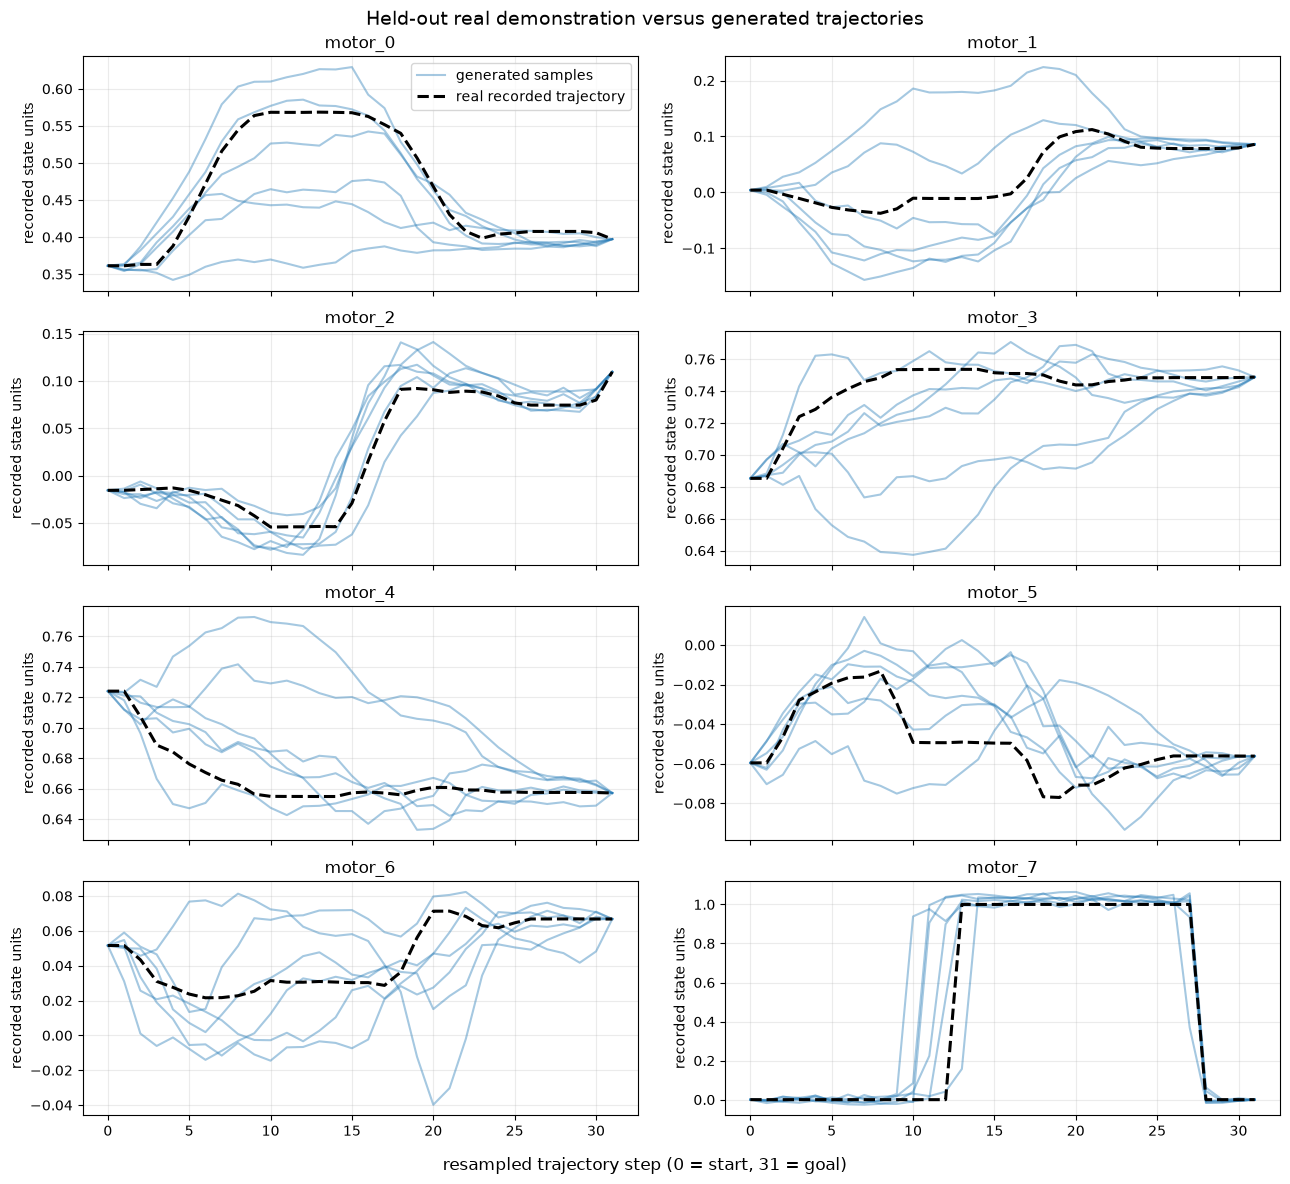

In [97]:
@torch.no_grad()
def sample(model, start, goal, task, count=6, ode_steps=ODE_STEPS):
    model.eval()
    start = start[None].repeat(count, 1).to(DEVICE)
    goal = goal[None].repeat(count, 1).to(DEVICE)
    task = task[None].repeat(count, 1).to(DEVICE)
    x = torch.randn(count, TRAJECTORY_STEPS-2, start.shape[-1], device=DEVICE)
    dt = 1.0 / ode_steps
    for i in range(ode_steps):
        t = torch.full((count,), i * dt, device=DEVICE)
        x = x + dt * model(t, x, start, goal, task)
    s = torch.linspace(0, 1, TRAJECTORY_STEPS, device=DEVICE)[None, :, None]
    result = (1-s) * start[:, None] + s * goal[:, None]
    result[:, 1:-1] += x
    return result.cpu()

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model'])
example, example_task = val_data[0]
generated = sample(model, example[0], example[-1], example_task, count=6)
generated_real = generated.numpy() * state_std[None, None] + state_mean[None, None]
example_real = example.numpy() * state_std[None] + state_mean[None]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for channel, ax in enumerate(axes.flat):
    for sample_index, path in enumerate(generated_real):
        # Add one legend entry even though all blue lines are generated samples.
        label = 'generated samples' if sample_index == 0 else None
        ax.plot(path[:, channel], color='tab:blue', alpha=.4, label=label)
    ax.plot(example_real[:, channel], 'k--', linewidth=2.2, label='real recorded trajectory')
    ax.set_title(f'motor_{channel}'); ax.set_ylabel('recorded state units'); ax.grid(alpha=.25)
axes[0, 0].legend(loc='best')
fig.suptitle('Held-out real demonstration versus generated trajectories', fontsize=14)
fig.supxlabel('resampled trajectory step (0 = start, 31 = goal)')
fig.tight_layout(); save_figure(fig, '03_initial_flow_samples.png'); plt.show()

### Quantitative trajectory comparison

There is no single classification-style **error rate** for a generated trajectory. Instead, the next cell reports several complementary diagnostics:

- **RMSE by motor:** deviation from the held-out demonstration, averaged over time and samples;
- **RMSE over time:** where along the trajectory the generated samples differ most; the shaded band shows variation between samples;
- **endpoint RMSE:** verifies the exact start/goal constraint; it should be approximately zero;
- **acceleration RMS:** compares trajectory smoothness using finite second differences; lower is smoother, but lower is not automatically more realistic;
- **sample diversity:** mean pairwise RMSE between generated trajectories. Zero would indicate that all random samples collapsed to the same path.

RMSE against one demonstration measures imitation, not task success. A generated motion can have nonzero RMSE and still be valid. Physical evaluation additionally requires decoded joint semantics, joint-limit checks, collision checks, and task-success labels.

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/04_initial_flow_diagnostics.png


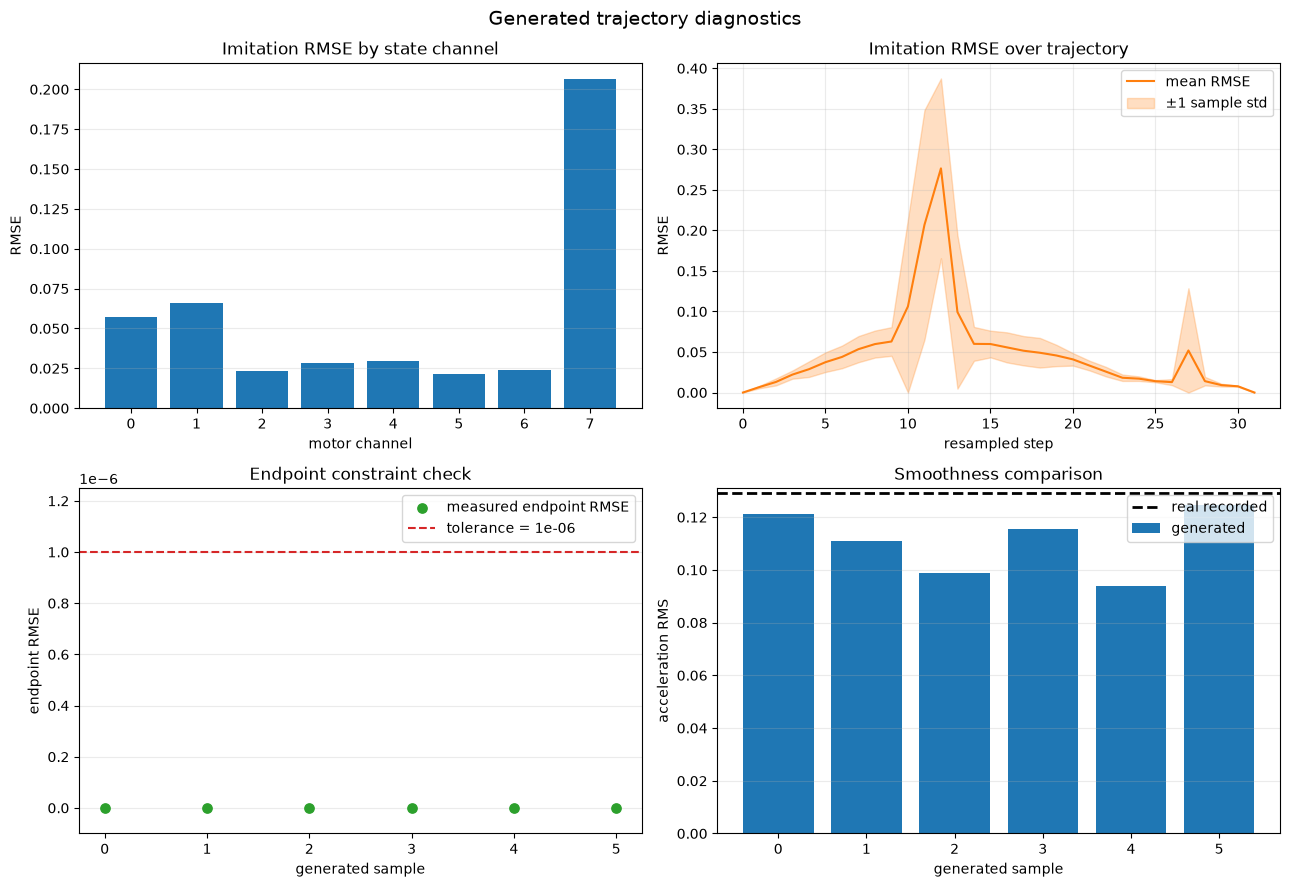

mean imitation RMSE: 0.087100
mean endpoint RMSE:  0.00000000
sample diversity:    0.089590
recorded accel RMS:  0.129296
generated accel RMS: 0.110916 ± 0.011176


In [98]:
# All metrics are computed in the original recorded state units.
error = generated_real - example_real[None, :, :]
num_samples, num_steps, num_channels = error.shape

# Imitation error: generated trajectories versus this one held-out demonstration.
sample_channel_rmse = np.sqrt(np.mean(error**2, axis=1))       # [sample, channel]
channel_rmse = sample_channel_rmse.mean(axis=0)                # [channel]
sample_time_rmse = np.sqrt(np.mean(error**2, axis=2))          # [sample, step]
time_rmse_mean = sample_time_rmse.mean(axis=0)
time_rmse_std = sample_time_rmse.std(axis=0)

# Endpoint error should be numerical noise because endpoints are inserted exactly.
endpoint_error = error[:, [0, -1], :]
endpoint_rmse = np.sqrt(np.mean(endpoint_error**2, axis=(1, 2)))

# Smoothness proxy from finite second differences.
generated_acceleration = np.diff(generated_real, n=2, axis=1)
recorded_acceleration = np.diff(example_real, n=2, axis=0)
generated_acceleration_rms = np.sqrt(np.mean(generated_acceleration**2, axis=(1, 2)))
recorded_acceleration_rms = np.sqrt(np.mean(recorded_acceleration**2))

# Diversity is the average distance over each unique pair of generated samples.
pairwise_rmse = []
for i in range(num_samples):
    for j in range(i + 1, num_samples):
        pairwise_rmse.append(np.sqrt(np.mean((generated_real[i] - generated_real[j])**2)))
diversity = float(np.mean(pairwise_rmse)) if pairwise_rmse else 0.0

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].bar(np.arange(num_channels), channel_rmse, color='tab:blue')
axes[0, 0].set(title='Imitation RMSE by state channel', xlabel='motor channel', ylabel='RMSE')
axes[0, 0].set_xticks(np.arange(num_channels)); axes[0, 0].grid(axis='y', alpha=.25)

steps = np.arange(num_steps)
axes[0, 1].plot(steps, time_rmse_mean, color='tab:orange', label='mean RMSE')
axes[0, 1].fill_between(steps, np.maximum(0, time_rmse_mean-time_rmse_std),
                        time_rmse_mean+time_rmse_std, color='tab:orange', alpha=.25, label='±1 sample std')
axes[0, 1].set(title='Imitation RMSE over trajectory', xlabel='resampled step', ylabel='RMSE')
axes[0, 1].legend(); axes[0, 1].grid(alpha=.25)

# Exact endpoints produce zero-height bars, so show markers against an explicit tolerance.
endpoint_tolerance = 1e-6
endpoint_x = np.arange(num_samples)
axes[1, 0].scatter(endpoint_x, endpoint_rmse, color='tab:green', s=45, zorder=3,
                   label='measured endpoint RMSE')
axes[1, 0].axhline(endpoint_tolerance, color='tab:red', linestyle='--',
                   label=f'tolerance = {endpoint_tolerance:g}')
axes[1, 0].set_ylim(-0.1 * endpoint_tolerance, 1.25 * endpoint_tolerance)
axes[1, 0].set_xticks(endpoint_x)
axes[1, 0].set(title='Endpoint constraint check', xlabel='generated sample', ylabel='endpoint RMSE')
axes[1, 0].legend(); axes[1, 0].grid(axis='y', alpha=.25)

axes[1, 1].bar(np.arange(num_samples), generated_acceleration_rms,
               color='tab:blue', label='generated')
axes[1, 1].axhline(recorded_acceleration_rms, color='black', linestyle='--',
                   linewidth=2, label='real recorded')
axes[1, 1].set(title='Smoothness comparison', xlabel='generated sample', ylabel='acceleration RMS')
axes[1, 1].legend(); axes[1, 1].grid(axis='y', alpha=.25)

fig.suptitle('Generated trajectory diagnostics', fontsize=14)
fig.tight_layout(); save_figure(fig, '04_initial_flow_diagnostics.png'); plt.show()

print(f'mean imitation RMSE: {np.sqrt(np.mean(error**2)):.6f}')
print(f'mean endpoint RMSE:  {endpoint_rmse.mean():.8f}')
print(f'sample diversity:    {diversity:.6f}')
print(f'recorded accel RMS:  {recorded_acceleration_rms:.6f}')
print(f'generated accel RMS: {generated_acceleration_rms.mean():.6f} ± {generated_acceleration_rms.std():.6f}')

### Interactive 3D UR5 animation (assumption-based)

The channel ranges are most consistent with an end-effector pose: `XYZ + quaternion + gripper`. They are **not consistent with six UR5 joint angles**. Consequently, the visualization below uses inverse kinematics (IK) to recover one plausible six-joint configuration for every pose.

Important consequences:

- IK is not unique; two different arm postures can produce the same tool pose.
- each frame is initialized from the preceding solution to favor continuous motion;
- the real motion is black and the selected generated motion is blue;
- faint trails show the two end-effector paths;
- an IK failure is shown in the diagnostic plot rather than silently accepted;
- edit the state mapping, quaternion order, frame transform, and IK weights in the setup cell if better metadata becomes available.

This is a geometrically valid UR5 reconstruction under the configured assumptions, but it is not proof of the robot's original recorded joint posture.

In [99]:
# Standard UR5 Denavit–Hartenberg dimensions in metres. Edit these for another model.
UR5_A = np.array([0.0, -0.42500, -0.39225, 0.0, 0.0, 0.0])
UR5_D = np.array([0.089159, 0.0, 0.0, 0.10915, 0.09465, 0.08230])
UR5_ALPHA = np.array([np.pi/2, 0.0, 0.0, np.pi/2, -np.pi/2, 0.0])
UR5_IK_BOUNDS = (-2 * np.pi * np.ones(6), 2 * np.pi * np.ones(6))
UR5_HOME = np.array([0.0, -np.pi/2, 0.0, -np.pi/2, 0.0, 0.0])

def dh_transform(theta, d, a, alpha):
    ct, st, ca, sa = np.cos(theta), np.sin(theta), np.cos(alpha), np.sin(alpha)
    return np.array([[ct, -st*ca,  st*sa, a*ct],
                     [st,  ct*ca, -ct*sa, a*st],
                     [0.,      sa,      ca,    d],
                     [0.,      0.,      0.,   1.]])

def ur5_forward_kinematics(joints):
    # Return every joint origin for drawing and the final tool transform for IK.
    transform = np.eye(4)
    points = [transform[:3, 3].copy()]
    for theta, d, a, alpha in zip(joints, UR5_D, UR5_A, UR5_ALPHA):
        transform = transform @ dh_transform(theta, d, a, alpha)
        points.append(transform[:3, 3].copy())
    return np.stack(points), transform

def state_to_target_pose(state):
    position = np.asarray(state)[list(POSITION_CHANNELS)].astype(float)
    quaternion = np.asarray(state)[list(QUATERNION_CHANNELS)].astype(float)
    if QUATERNION_ORDER == 'wxyz':
        quaternion = quaternion[[1, 2, 3, 0]]  # SciPy expects xyzw.
    elif QUATERNION_ORDER != 'xyzw':
        raise ValueError("QUATERNION_ORDER must be 'xyzw' or 'wxyz'")
    norm = np.linalg.norm(quaternion)
    if norm < 1e-8:
        raise ValueError('Quaternion norm is zero; check QUATERNION_CHANNELS.')
    quaternion /= norm  # Generated channels need not remain exactly unit length.

    pose = np.eye(4)
    pose[:3, :3] = Rotation.from_quat(quaternion).as_matrix()
    pose[:3, 3] = position
    return DATA_TO_UR5_BASE @ pose

def ik_residual(joints, target_pose):
    _, current_pose = ur5_forward_kinematics(joints)
    position_error = target_pose[:3, 3] - current_pose[:3, 3]
    rotation_error = Rotation.from_matrix(
        target_pose[:3, :3] @ current_pose[:3, :3].T
    ).as_rotvec()
    return np.r_[IK_POSITION_WEIGHT * position_error,
                 IK_ORIENTATION_WEIGHT * rotation_error]

def solve_ik_trajectory(states, initial_joints=UR5_HOME):
    # Warm-starting from the preceding frame selects a relatively continuous IK branch.
    solutions, position_errors, orientation_errors, successes = [], [], [], []
    guess = np.asarray(initial_joints, dtype=float).copy()
    for state in states:
        target = state_to_target_pose(state)
        result = least_squares(ik_residual, guess, args=(target,), bounds=UR5_IK_BOUNDS,
                               max_nfev=300, ftol=1e-9, xtol=1e-9, gtol=1e-9)
        guess = result.x
        _, achieved = ur5_forward_kinematics(guess)
        position_error = np.linalg.norm(target[:3, 3] - achieved[:3, 3])
        orientation_error = np.linalg.norm(Rotation.from_matrix(
            target[:3, :3] @ achieved[:3, :3].T).as_rotvec())
        solutions.append(guess.copy())
        position_errors.append(position_error)
        orientation_errors.append(orientation_error)
        successes.append(result.success and position_error < 0.01 and orientation_error < 0.10)
    return (np.stack(solutions), np.asarray(position_errors),
            np.asarray(orientation_errors), np.asarray(successes))

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/05_robot_reconstruction_animation.html
saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/05_robot_reconstruction_steps.png


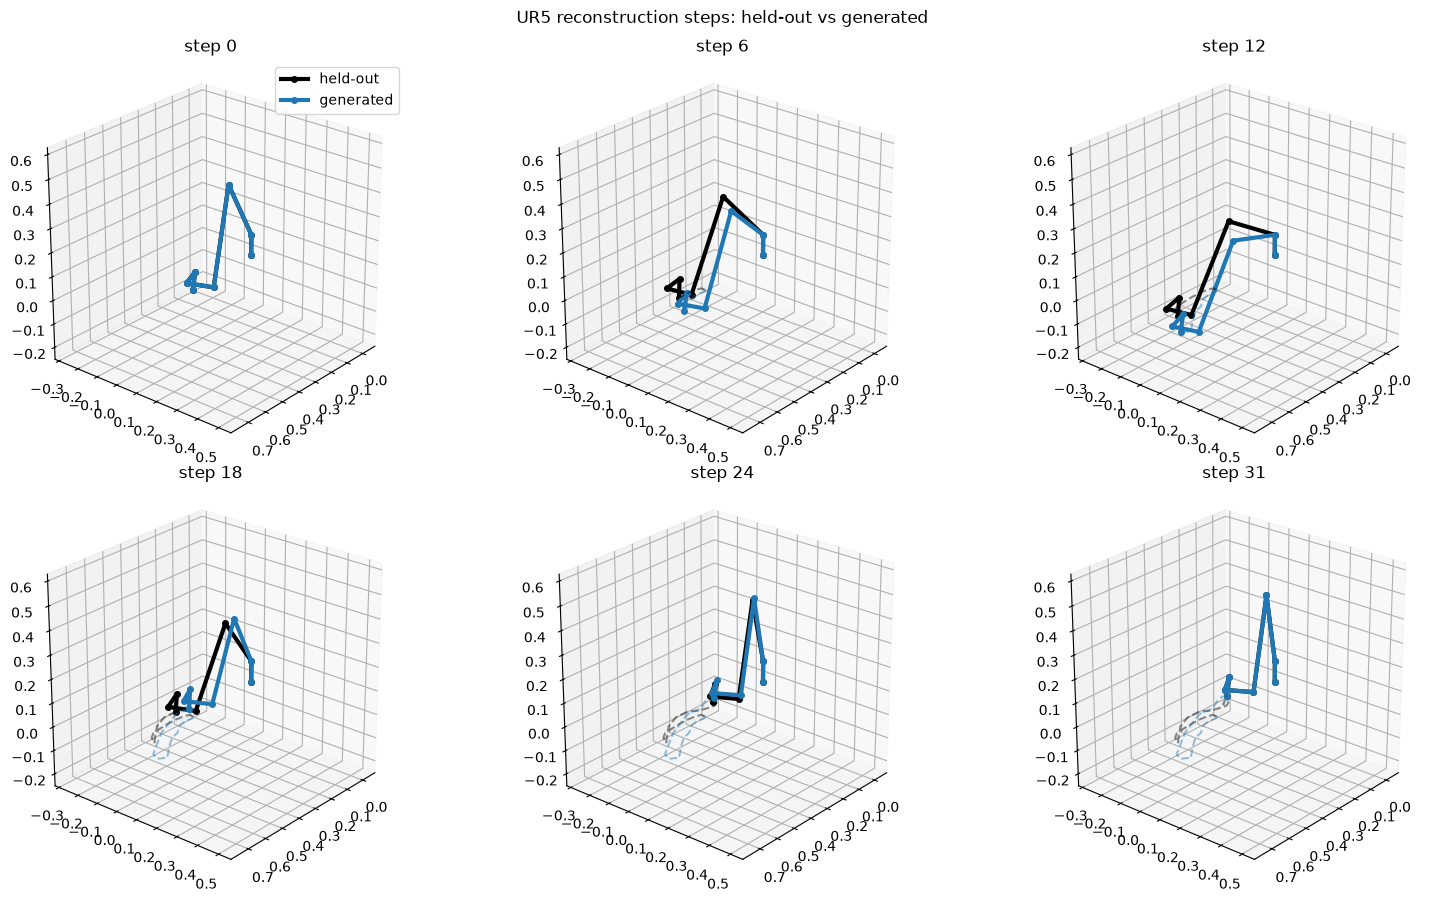

In [131]:
# Reconstruct one plausible joint trajectory for the real and selected generated poses.
selected_generated = generated_real[ANIMATION_GENERATED_SAMPLE]
real_joints, real_pos_error, real_rot_error, real_ok = solve_ik_trajectory(example_real)
generated_joints, gen_pos_error, gen_rot_error, gen_ok = solve_ik_trajectory(
    selected_generated, initial_joints=real_joints[0])

real_links = np.stack([ur5_forward_kinematics(q)[0] for q in real_joints])
generated_links = np.stack([ur5_forward_kinematics(q)[0] for q in generated_joints])
real_tool_path = real_links[:, -1]
generated_tool_path = generated_links[:, -1]

def robot_link_mesh(points, name, color, radius=0.025, sides=12):
    # Build one Mesh3d containing a cylinder for every link segment.
    vertices, triangles = [], []
    angles = np.linspace(0, 2*np.pi, sides, endpoint=False)
    for start, end in zip(points[:-1], points[1:]):
        axis = end - start
        length = np.linalg.norm(axis)
        if length < 1e-10:
            continue
        axis /= length
        reference = np.array([0., 0., 1.]) if abs(axis[2]) < .9 else np.array([1., 0., 0.])
        basis_u = np.cross(axis, reference); basis_u /= np.linalg.norm(basis_u)
        basis_v = np.cross(axis, basis_u)
        ring_start = start + radius * (np.cos(angles)[:, None] * basis_u +
                                       np.sin(angles)[:, None] * basis_v)
        ring_end = end + radius * (np.cos(angles)[:, None] * basis_u +
                                   np.sin(angles)[:, None] * basis_v)
        offset = len(vertices)
        vertices.extend(ring_start); vertices.extend(ring_end)
        for side in range(sides):
            nxt = (side + 1) % sides
            triangles.extend([(offset + side, offset + nxt, offset + sides + side),
                              (offset + nxt, offset + sides + nxt, offset + sides + side)])
    vertices = np.asarray(vertices); triangles = np.asarray(triangles)
    return go.Mesh3d(x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
                     i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
                     color=color, opacity=.72, flatshading=False,
                     lighting=dict(ambient=.45, diffuse=.8, specular=.35),
                     name=name, legendgroup=name, showlegend=True)

def robot_traces(points, name, color):
    links = robot_link_mesh(points, name, color)
    joints = go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2],
                          mode='markers', name=f'{name} joints',
                          marker=dict(color=color, size=7,
                                      line=dict(color='white', width=1)),
                          legendgroup=name, showlegend=False)
    return [links, joints]

def trail_trace(points, frame, name, color):
    trail = points[:frame+1]
    return go.Scatter3d(x=trail[:, 0], y=trail[:, 1], z=trail[:, 2],
                        mode='lines', name=name,
                        line=dict(color=color, width=4, dash='dot'), opacity=.55)

frames_3d = []
for frame in range(num_steps):
    frames_3d.append(go.Frame(
        name=str(frame),
        data=[*robot_traces(real_links[frame], 'real UR5 reconstruction', 'black'),
              *robot_traces(generated_links[frame], 'generated UR5 reconstruction', '#1f77b4'),
              trail_trace(real_tool_path, frame, 'real tool path', 'black'),
              trail_trace(generated_tool_path, frame, 'generated tool path', '#1f77b4')],
        traces=list(range(6))))

all_points = np.concatenate([real_links.reshape(-1, 3), generated_links.reshape(-1, 3)])
centre = (all_points.min(0) + all_points.max(0)) / 2
radius = max((all_points.max(0) - all_points.min(0)).max() / 2, 0.35) + 0.08
axis_ranges = [[centre[i]-radius, centre[i]+radius] for i in range(3)]

figure_3d = go.Figure(data=frames_3d[0].data, frames=frames_3d)
figure_3d.update_layout(
    title='3D UR5 reconstruction — black: real, blue: generated',
    width=900, height=700,
    scene=dict(xaxis=dict(title='x [m]', range=axis_ranges[0]),
               yaxis=dict(title='y [m]', range=axis_ranges[1]),
               zaxis=dict(title='z [m]', range=axis_ranges[2]),
               aspectmode='cube'),
    updatemenus=[dict(type='buttons', showactive=False, buttons=[
        dict(label='Play', method='animate', args=[None,
             dict(frame=dict(duration=ANIMATION_FRAME_MS, redraw=True), fromcurrent=True)]),
        dict(label='Pause', method='animate', args=[[None],
             dict(frame=dict(duration=0, redraw=False), mode='immediate')])])],
    sliders=[dict(currentvalue=dict(prefix='trajectory step: '),
                  steps=[dict(method='animate', label=str(i), args=[[str(i)],
                              dict(mode='immediate', frame=dict(duration=0, redraw=True))])
                         for i in range(num_steps)])])
robot_animation_path = RESULTS_DIR / '05_robot_reconstruction_animation.html'
figure_3d.write_html(robot_animation_path, include_plotlyjs='cdn', auto_play=False)
print('saved:', robot_animation_path)

# Save representative robot steps as one README-friendly PNG contact sheet.
snapshot_steps = np.linspace(0, num_steps-1, 6, dtype=int)
snapshot_figure = plt.figure(figsize=(16, 9))
for panel, frame in enumerate(snapshot_steps, 1):
    ax = snapshot_figure.add_subplot(2, 3, panel, projection='3d')
    for links, color, label in [(real_links, 'black', 'held-out'),
                                (generated_links, 'tab:blue', 'generated')]:
        points = links[frame]
        ax.plot(points[:, 0], points[:, 1], points[:, 2], 'o-',
                color=color, linewidth=3, markersize=4, label=label)
    ax.plot(real_tool_path[:frame+1, 0], real_tool_path[:frame+1, 1],
            real_tool_path[:frame+1, 2], '--', color='black', alpha=.45)
    ax.plot(generated_tool_path[:frame+1, 0], generated_tool_path[:frame+1, 1],
            generated_tool_path[:frame+1, 2], '--', color='tab:blue', alpha=.45)
    ax.set_title(f'step {frame}')
    ax.set(xlim=axis_ranges[0], ylim=axis_ranges[1], zlim=axis_ranges[2])
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=25, azim=40)
    if panel == 1: ax.legend()
snapshot_figure.suptitle('UR5 reconstruction steps: held-out vs generated')
snapshot_figure.tight_layout()
save_figure(snapshot_figure, '05_robot_reconstruction_steps.png')
plt.show()
figure_3d.show()

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/06_robot_ik_residuals.png


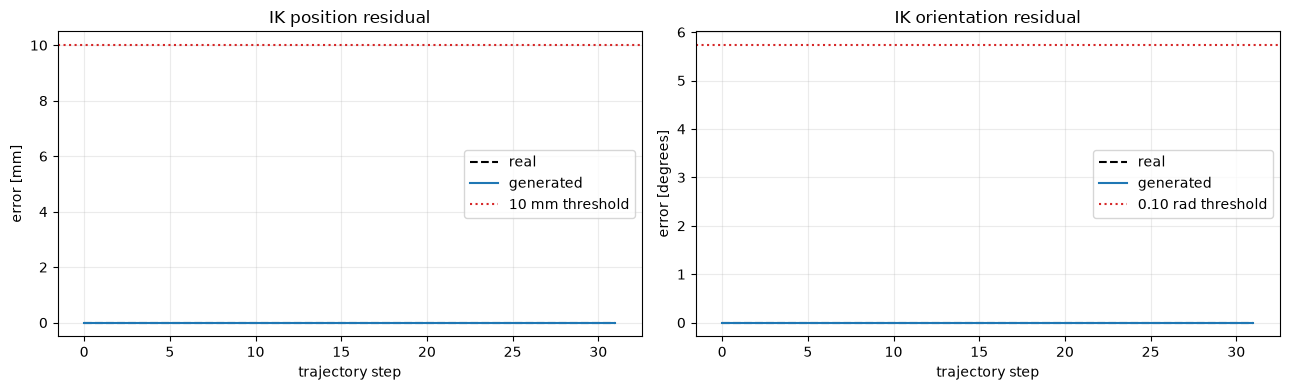

real IK accepted:      32/32 frames
generated IK accepted: 32/32 frames


In [101]:
# Never trust an IK animation without checking how closely it reaches each target pose.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(real_pos_error * 1000, 'k--', label='real')
axes[0].plot(gen_pos_error * 1000, color='tab:blue', label='generated')
axes[0].axhline(10, color='tab:red', linestyle=':', label='10 mm threshold')
axes[0].set(title='IK position residual', xlabel='trajectory step', ylabel='error [mm]')
axes[0].legend(); axes[0].grid(alpha=.25)

axes[1].plot(np.rad2deg(real_rot_error), 'k--', label='real')
axes[1].plot(np.rad2deg(gen_rot_error), color='tab:blue', label='generated')
axes[1].axhline(np.rad2deg(.10), color='tab:red', linestyle=':', label='0.10 rad threshold')
axes[1].set(title='IK orientation residual', xlabel='trajectory step', ylabel='error [degrees]')
axes[1].legend(); axes[1].grid(alpha=.25)
fig.tight_layout(); save_figure(fig, '06_robot_ik_residuals.png'); plt.show()

print(f'real IK accepted:      {real_ok.sum()}/{len(real_ok)} frames')
print(f'generated IK accepted: {gen_ok.sum()}/{len(gen_ok)} frames')
if not (real_ok.all() and gen_ok.all()):
    print('Warning: failed frames are not reliable. Check channel mapping, quaternion order,')
    print('DATA_TO_UR5_BASE, reachability, and generated quaternion quality.')

## 8. Train a diverse ensemble of expert teachers

A single network can learn the flow, but it also has a single pattern of mistakes. Here we train three architectures on the same target velocity:

- the **MLP expert** from Section 6 sees the whole flattened trajectory at once;
- a **temporal-convolution expert** emphasizes local motion patterns;
- a **Transformer expert** learns which distant waypoints should interact.

Because every expert predicts the same quantity, their velocities can be averaged directly. The architectures differ enough that agreement is meaningful and disagreement is a useful uncertainty signal.

### 8.1 Experiment settings

These values control only the new teacher and student experiments. Start with 1–5 epochs to check that everything runs, then use the defaults for a real comparison. `DISTILL_ROLLOUT_STEPS` controls how finely the student traverses flow time while collecting its own states.

In [102]:
EXPERT_EPOCHS = 300
DISTILL_EPOCHS = 300
STUDENT_HIDDEN = 192
SHARED_TEMPORAL_DILATIONS = (1, 2, 4, 8, 4, 2)

DISTILL_LEARNING_RATE = 2e-4
DISTILL_SUPERVISED_WEIGHT = 1.00
DISTILL_SMOOTHNESS_WEIGHT = 0.10
DISTILL_ROLLOUT_STEPS = 16

### 8.2 Temporal-convolution building block

A residual block applies two temporal convolutions and adds the input back. Dilation expands the temporal receptive field without making the kernel large: dilation 1 sees nearby waypoints, while dilation 8 connects more distant ones. Group normalization is stable for the relatively small batches used here.

In [103]:
class ResidualConvBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv1d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

### 8.3 Temporal-convolution expert

`Conv1d` expects `[batch, channels, time]`, so the trajectory axes are transposed on entry and restored on exit. The condition—flow time, start, goal, and task—is projected once and broadcast to every waypoint. Four dilations let the model combine fine and coarse motion structure.

In [104]:
class TemporalConvFlow(nn.Module):
    def __init__(self, state_dim, num_tasks, channels=256, dilations=(1, 2, 4, 8)):
        super().__init__()
        condition_dim = 32 + 2 * state_dim + num_tasks
        self.time = TimeEmbedding(32)
        self.condition = nn.Sequential(nn.Linear(condition_dim, channels), nn.SiLU())
        self.input = nn.Conv1d(state_dim, channels, 1)
        self.blocks = nn.Sequential(
            *[ResidualConvBlock(channels, dilation) for dilation in dilations]
        )
        self.output = nn.Sequential(
            nn.GroupNorm(8, channels), nn.SiLU(), nn.Conv1d(channels, state_dim, 1)
        )

    def forward(self, t, x, start, goal, task):
        condition = torch.cat([self.time(t), start, goal, task], dim=-1)
        condition = self.condition(condition)[:, :, None]
        hidden = self.input(x.transpose(1, 2)) + condition
        velocity = self.output(self.blocks(hidden))
        return velocity.transpose(1, 2)

### 8.4 Transformer expert

Each interior waypoint becomes a token. A learned positional embedding tells the network where that token lies along the trajectory. Self-attention then allows any waypoint to use information from any other waypoint. The condition is added to every token, ensuring attention remains specific to flow time, endpoints, and task.

In [105]:
class TransformerFlow(nn.Module):
    def __init__(self, steps, state_dim, num_tasks, width=256, layers=4, heads=8):
        super().__init__()
        condition_dim = 32 + 2 * state_dim + num_tasks
        self.time = TimeEmbedding(32)
        self.token = nn.Linear(state_dim, width)
        self.condition = nn.Linear(condition_dim, width)
        self.position = nn.Parameter(torch.randn(1, steps - 2, width) * 0.02)

        layer = nn.TransformerEncoderLayer(
            width, heads, 4 * width, dropout=0.05,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            layer, layers, norm=nn.LayerNorm(width)
        )
        self.output = nn.Linear(width, state_dim)

    def forward(self, t, x, start, goal, task):
        condition = torch.cat([self.time(t), start, goal, task], dim=-1)
        hidden = self.token(x)
        hidden = hidden + self.position[:, :x.shape[1]]
        hidden = hidden + self.condition(condition)[:, None]
        return self.output(self.encoder(hidden))

### 8.5 Instantiate and size the experts

All teachers—including the initial flow model—now use temporal convolutions. The four specialists use exactly the same channel width and dilation stack; only their training objectives differ. No MLP participates in teaching, ensemble inference, or distillation.

In [ ]:
state_dim = trajectories.shape[-1]
teacher_specs = {
    'rmse': dict(channels=STUDENT_HIDDEN, objective='rmse'),
    'acceleration': dict(channels=STUDENT_HIDDEN, objective='acceleration'),
    'validation': dict(channels=STUDENT_HIDDEN, objective='validation'),
    # Latency is measured directly; architecture is held fixed for a fair comparison.
    'base': dict(channels=STUDENT_HIDDEN, objective='base'),
}
specialist_teachers = {
    name: TemporalConvFlow(
        state_dim, NUM_TASKS, channels=spec['channels'],
        dilations=SHARED_TEMPORAL_DILATIONS,
    ).to(DEVICE)
    for name, spec in teacher_specs.items()
}

def parameter_count(network):
    return sum(parameter.numel() for parameter in network.parameters())

for name, teacher in specialist_teachers.items():
    print(f'{name:12s} ConvNet:', f'{parameter_count(teacher):,}', 'parameters')

rmse         ConvNet: 905,672 parameters
acceleration ConvNet: 905,672 parameters
validation   ConvNet: 905,672 parameters
latency      ConvNet: 905,672 parameters


### 8.6 Validation helper

Validation uses exactly the same flow-matching objective as training, but disables gradients and dropout. The interpolation time and noise are sampled afresh, so small variations between calls are expected.

In [107]:
def evaluate_flow(network, loader):
    network.eval()
    losses = []
    with torch.no_grad():
        for trajectory, task in loader:
            trajectory = trajectory.to(DEVICE)
            task = task.to(DEVICE)
            losses.append(flow_loss(network, trajectory, task).item())
    return float(np.mean(losses))

### 8.7 Reusable expert training function

Each convolutional specialist receives its own optimizer, schedule, objective, and checkpoint. The RMSE specialist adds clean-trajectory reconstruction error; the acceleration specialist penalizes second differences; and the validation and latency specialists use the standard flow objective. All use the same architecture and epoch count. Latency is measured rather than differentiated, so the latency specialist is now a controlled replicate rather than a smaller network.

In [108]:
def specialist_flow_loss(network, trajectory, task, objective):
    data = residual_target(trajectory)
    noise = torch.randn_like(data)
    t = torch.rand(len(data), device=data.device)
    x_t = (1-t[:, None, None]) * noise + t[:, None, None] * data
    prediction = network(t, x_t, trajectory[:, 0], trajectory[:, -1], task)
    velocity_loss = nn.functional.mse_loss(prediction, data - noise)
    predicted_clean = x_t + (1-t[:, None, None]) * prediction

    if objective == 'rmse':
        reconstruction_rmse = torch.sqrt(
            nn.functional.mse_loss(predicted_clean, data) + 1e-8
        )
        return velocity_loss + 0.35 * reconstruction_rmse
    if objective == 'acceleration':
        # Residual endpoints are fixed at zero; linear reference has zero acceleration.
        padded = nn.functional.pad(predicted_clean, (0, 0, 1, 1))
        acceleration = padded[:, 2:] - 2*padded[:, 1:-1] + padded[:, :-2]
        return velocity_loss + 0.30 * acceleration.square().mean()
    if objective in ('validation', 'latency'):
        return velocity_loss
    raise ValueError(f'unknown specialist objective: {objective}')


@torch.no_grad()
def evaluate_specialist(network, loader, objective):
    network.eval()
    values = []
    for trajectory, task in loader:
        trajectory = trajectory.to(DEVICE)
        task = task.to(DEVICE)
        values.append(specialist_flow_loss(network, trajectory, task, objective).item())
    return float(np.mean(values))


def train_expert(name, network, objective, epochs=EXPERT_EPOCHS):
    optimizer = torch.optim.AdamW(
        network.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    path = PROJECT_ROOT / 'runs' / f'berkeley_ur5_{name}.pt'
    best = float('inf')
    curve = {'train': [], 'val': []}

    for epoch in range(1, epochs + 1):
        network.train()
        batch_losses = []

        for trajectory, task in train_loader:
            trajectory = trajectory.to(DEVICE)
            task = task.to(DEVICE)
            loss = specialist_flow_loss(network, trajectory, task, objective)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(network.parameters(), 1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        scheduler.step()
        train_value = float(np.mean(batch_losses))
        val_value = evaluate_specialist(network, val_loader, objective)
        curve['train'].append(train_value)
        curve['val'].append(val_value)

        if val_value < best:
            best = val_value
            torch.save({'model': network.state_dict(), 'best_val': best}, path)

        if epoch == 1 or epoch % 10 == 0:
            print(f'{name:11s} | epoch {epoch:03d} | '
                  f'train {train_value:.5f} | val {val_value:.5f}')

    saved = torch.load(path, map_location=DEVICE, weights_only=False)
    network.load_state_dict(saved['model'])
    return curve, saved['best_val'], path

### 8.8 Train the convolutional specialists

This is the computationally expensive teacher-training cell. It trains four ConvNets independently; neither the MLP nor Transformer participates. Each saved checkpoint is selected using its own held-out specialist objective.

In [109]:
expert_curves = {}
expert_val_losses = {}

for name, expert in specialist_teachers.items():
    objective = teacher_specs[name]['objective']
    curve, best, path = train_expert(name, expert, objective)
    expert_curves[name] = curve
    expert_val_losses[name] = best
    print('best checkpoint:', path)

print('best specialist validation objectives:', expert_val_losses)

rmse        | epoch 001 | train 1.69286 | val 1.44124
rmse        | epoch 010 | train 0.68726 | val 0.74822
rmse        | epoch 020 | train 0.59216 | val 0.61619
rmse        | epoch 030 | train 0.54044 | val 0.56477
rmse        | epoch 040 | train 0.50792 | val 0.52101
rmse        | epoch 050 | train 0.47011 | val 0.52083
rmse        | epoch 060 | train 0.46686 | val 0.49037
rmse        | epoch 070 | train 0.46134 | val 0.51310
rmse        | epoch 080 | train 0.44879 | val 0.46519
rmse        | epoch 090 | train 0.43275 | val 0.45898
rmse        | epoch 100 | train 0.41946 | val 0.47221
rmse        | epoch 110 | train 0.42051 | val 0.42397
rmse        | epoch 120 | train 0.40843 | val 0.44154
rmse        | epoch 130 | train 0.40298 | val 0.41705
rmse        | epoch 140 | train 0.38619 | val 0.41863
rmse        | epoch 150 | train 0.39665 | val 0.44550
rmse        | epoch 160 | train 0.37208 | val 0.43688
rmse        | epoch 170 | train 0.39788 | val 0.41650
rmse        | epoch 180 | tr

### 8.9 Inspect teacher learning curves

Training and validation are shown separately. A widening gap suggests overfitting; a curve still falling at the final epoch suggests training longer. Compare architectures by validation—not training—loss.

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/07_specialist_training_curves.png


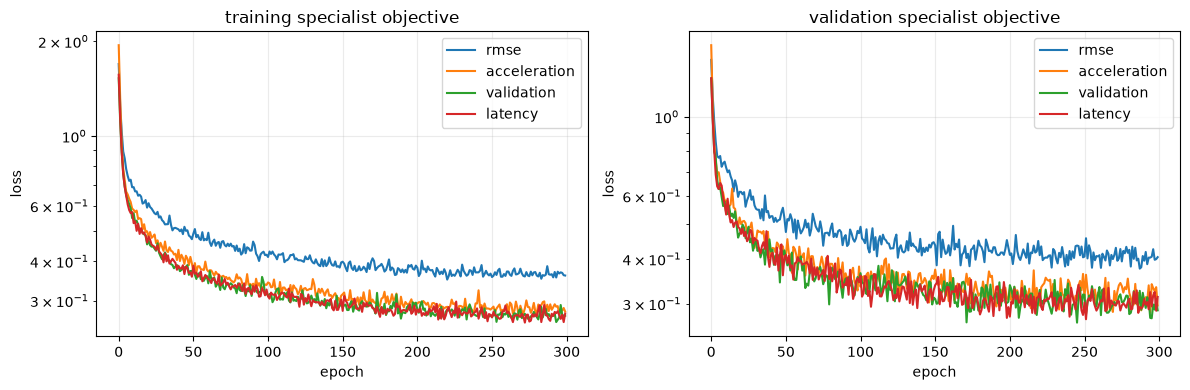

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, curve in expert_curves.items():
    axes[0].plot(curve['train'], label=name)
    axes[1].plot(curve['val'], label=name)

for ax, title in zip(axes, ['training', 'validation']):
    ax.set(title=f'{title} specialist objective', xlabel='epoch', ylabel='loss', yscale='log')
    ax.grid(alpha=.25)
    ax.legend()

plt.tight_layout()
save_figure(fig, '07_specialist_training_curves.png')
plt.show()

## 9. Build the frozen teacher ensemble

Distillation treats the convolutional specialists as fixed label generators. Freezing parameters prevents accidental updates and saves gradient memory. The MLP and Transformer are deliberately excluded.

In [111]:
teachers = specialist_teachers

for teacher in teachers.values():
    teacher.eval()
    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

### 9.1 Choose ensemble weights

Specialist objectives have different numerical scales, so inverse-loss weighting would not be meaningful. These explicit weights prioritize held-out accuracy and smoothness while retaining a smaller contribution from the compact latency specialist. Tune them using the final rollout table, never training loss alone.

In [112]:
teacher_weights = {
    'rmse': 0.30,
    'acceleration': 0.30,
    'validation': 0.30,
    'latency': 0.10,
}

print('ensemble weights:', teacher_weights)
print('weight sum:', sum(teacher_weights.values()))

ensemble weights: {'rmse': 0.3, 'acceleration': 0.3, 'validation': 0.3, 'latency': 0.1}
weight sum: 1.0


### 9.2 Ensemble velocity function

Every teacher sees the exact same noisy trajectory state and condition. Their velocity tensors have identical shapes, so the weighted mean is another valid velocity. `return_members=True` is useful for measuring disagreement without running the teachers twice.

In [113]:
@torch.no_grad()
def ensemble_velocity(t, x, start, goal, task, return_members=False):
    members = {
        name: teacher(t, x, start, goal, task)
        for name, teacher in teachers.items()
    }
    mean = sum(
        teacher_weights[name] * value
        for name, value in members.items()
    )
    return (mean, members) if return_members else mean

### 9.3 Check shapes and teacher disagreement

The diagnostic below queries all experts at random validation states. Disagreement is the root mean variance across teachers. A value near zero means the ensemble adds little diversity; a very large value can indicate that one expert failed or that the state lies outside the demonstrations.

In [114]:
trajectory, task = next(iter(val_loader))
trajectory = trajectory.to(DEVICE)
task = task.to(DEVICE)

x = torch.randn_like(residual_target(trajectory))
t = torch.rand(len(x), device=DEVICE)
ensemble_target, member_targets = ensemble_velocity(
    t, x, trajectory[:, 0], trajectory[:, -1], task,
    return_members=True,
)

member_stack = torch.stack(list(member_targets.values()))
disagreement = member_stack.var(dim=0).mean().sqrt()
print('ensemble target:', tuple(ensemble_target.shape))
print('teacher disagreement RMSE:', disagreement.item())

ensemble target: (100, 30, 8)
teacher disagreement RMSE: 0.17464789748191833


## 10. Distill the ensemble into a compact student

The student is now a larger, temporally structured ConvNet rather than a flattened MLP. Six dilated residual blocks model local and long-range waypoint relationships while remaining much smaller and faster than the complete teacher ensemble.

In [115]:
class StudentTemporalConvFlow(TemporalConvFlow):
    def __init__(self, state_dim, num_tasks, channels=STUDENT_HIDDEN):
        super().__init__(
            state_dim, num_tasks, channels=channels,
            dilations=SHARED_TEMPORAL_DILATIONS,
        )

### 10.1 Decode residuals and measure smoothness

The networks model only the 30 interior residuals. `decode_residual` restores the straight-line reference and inserts the recorded endpoints exactly. The smoothness metric uses second finite differences, a discrete approximation to acceleration.

In [116]:
def decode_residual(x, start, goal):
    steps = x.shape[1] + 2
    s = torch.linspace(0, 1, steps, device=x.device)[None, :, None]
    reference = (1-s) * start[:, None] + s * goal[:, None]
    return torch.cat([
        reference[:, :1],
        reference[:, 1:-1] + x,
        reference[:, -1:],
    ], dim=1)


def acceleration_loss(trajectory):
    acceleration = (
        trajectory[:, 2:]
        - 2 * trajectory[:, 1:-1]
        + trajectory[:, :-2]
    )
    return acceleration.square().mean()

### 10.2 Collect one on-policy state

“On-policy” means the student, not the teachers or demonstration interpolation, produces the queried state. We start from Gaussian noise, randomly choose a rollout depth, and advance with Euler steps using the current student. The frozen ensemble then supplies the desired velocity at that reached state.

Collection uses `no_grad`: the student is trained to match the label at the resulting state, not by backpropagating through the entire route used to reach it.

In [117]:
@torch.no_grad()
def collect_on_policy_state(
    student, trajectory, task, rollout_steps=DISTILL_ROLLOUT_STEPS
):
    start = trajectory[:, 0]
    goal = trajectory[:, -1]
    x = torch.randn_like(residual_target(trajectory))
    depth = int(torch.randint(0, rollout_steps, ()).item())
    dt = 1.0 / rollout_steps

    for step in range(depth):
        t = torch.full((len(x),), step * dt, device=x.device)
        velocity = student(t, x, start, goal, task)
        x = x + dt * velocity

    t = torch.full((len(x),), depth * dt, device=x.device)
    target = ensemble_velocity(t, x, start, goal, task)
    return t, x, target

### 10.3 Instantiate the student

The student and every individual teacher now have the same architecture and parameter count. The printed ratio compares one student with the complete four-model ensemble.

In [118]:
student = StudentTemporalConvFlow(
    state_dim, NUM_TASKS, channels=STUDENT_HIDDEN
).to(DEVICE)

ensemble_parameters = sum(parameter_count(teacher) for teacher in teachers.values())
compression = ensemble_parameters / parameter_count(student)
print('student parameters:', f'{parameter_count(student):,}')
print('compression versus full ensemble:', f'{compression:.2f}x')

student parameters: 905,672
compression versus full ensemble: 4.00x


### 10.4 Configure student optimization

The student gets its own optimizer and checkpoint. `student_history` keeps every objective component separate; this matters because a falling total can otherwise hide a worsening imitation term.

In [119]:
student_optimizer = torch.optim.AdamW(
    student.parameters(), lr=DISTILL_LEARNING_RATE, weight_decay=1e-4
)
student_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    student_optimizer, T_max=DISTILL_EPOCHS, eta_min=1e-6
)
student_history = {
    'total': [],
    'imitation': [],
    'supervised': [],
    'smoothness': [],
}
student_checkpoint = (
    PROJECT_ROOT / 'runs' / 'berkeley_ur5_distilled_conv_student.pt'
)
best_student_val = float('inf')

### 10.5 Train by combining three signals

For each demonstration batch:

1. **Imitation** matches the teacher ensemble at a student-generated state.
2. **Supervised flow matching** anchors the student to real demonstrations and prevents it from inheriting every teacher bias.
3. **Smoothness** weakly discourages abrupt waypoint-to-waypoint acceleration after one proposed Euler step.

Only the student optimizer steps. Teacher parameters are frozen and ensemble targets are detached by `no_grad`.

In [120]:
for epoch in range(1, DISTILL_EPOCHS + 1):
    student.train()
    epoch_values = {name: [] for name in student_history}

    for trajectory, task in train_loader:
        trajectory = trajectory.to(DEVICE)
        task = task.to(DEVICE)
        start, goal = trajectory[:, 0], trajectory[:, -1]

        t, x_t, ensemble_target = collect_on_policy_state(
            student, trajectory, task
        )
        prediction = student(t, x_t, start, goal, task)
        imitation = nn.functional.mse_loss(prediction, ensemble_target)

        data = residual_target(trajectory)
        noise = torch.randn_like(data)
        data_t = torch.rand(len(data), device=DEVICE)
        interpolated = (
            (1-data_t[:, None, None]) * noise
            + data_t[:, None, None] * data
        )
        supervised_prediction = student(
            data_t, interpolated, start, goal, task
        )
        supervised = nn.functional.mse_loss(
            supervised_prediction, data - noise
        )

        # Estimate the clean t=1 residual; do not smooth the noisy intermediate state.
        predicted_next = x_t + (1-t[:, None, None]) * prediction
        smoothness = acceleration_loss(
            decode_residual(predicted_next, start, goal)
        )
        total = (
            imitation
            + DISTILL_SUPERVISED_WEIGHT * supervised
            + DISTILL_SMOOTHNESS_WEIGHT * smoothness
        )

        student_optimizer.zero_grad(set_to_none=True)
        total.backward()
        nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        student_optimizer.step()

        for name, value in [
            ('total', total),
            ('imitation', imitation),
            ('supervised', supervised),
            ('smoothness', smoothness),
        ]:
            epoch_values[name].append(value.item())

    student_scheduler.step()
    for name in student_history:
        student_history[name].append(float(np.mean(epoch_values[name])))

    student_val = evaluate_flow(student, val_loader)
    if student_val < best_student_val:
        best_student_val = student_val
        torch.save({
            'model': student.state_dict(),
            'best_val': best_student_val,
            'teacher_weights': teacher_weights,
        }, student_checkpoint)

    if epoch == 1 or epoch % 10 == 0:
        print(f'student | epoch {epoch:03d} | '
              f'distill {student_history["total"][-1]:.5f} | '
              f'validation {student_val:.5f}')

student | epoch 001 | distill 3.02439 | validation 1.03944
student | epoch 010 | distill 0.73912 | validation 0.53482
student | epoch 020 | distill 0.56305 | validation 0.42601
student | epoch 030 | distill 0.49670 | validation 0.38847
student | epoch 040 | distill 0.44717 | validation 0.35881
student | epoch 050 | distill 0.37349 | validation 0.36113
student | epoch 060 | distill 0.36332 | validation 0.37113
student | epoch 070 | distill 0.34419 | validation 0.33880
student | epoch 080 | distill 0.32810 | validation 0.30220
student | epoch 090 | distill 0.32296 | validation 0.31072
student | epoch 100 | distill 0.29613 | validation 0.29433
student | epoch 110 | distill 0.31158 | validation 0.32434
student | epoch 120 | distill 0.31144 | validation 0.31102
student | epoch 130 | distill 0.30370 | validation 0.31338
student | epoch 140 | distill 0.29732 | validation 0.29497
student | epoch 150 | distill 0.28442 | validation 0.28419
student | epoch 160 | distill 0.29786 | validation 0.270

### 10.6 Restore and inspect the best student

As with the teachers, we reload the best validation checkpoint. The log-scale plot makes differently sized loss components visible on the same axes. Their absolute scales need not match; their trends are the useful part.

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/08_student_training_curves.png


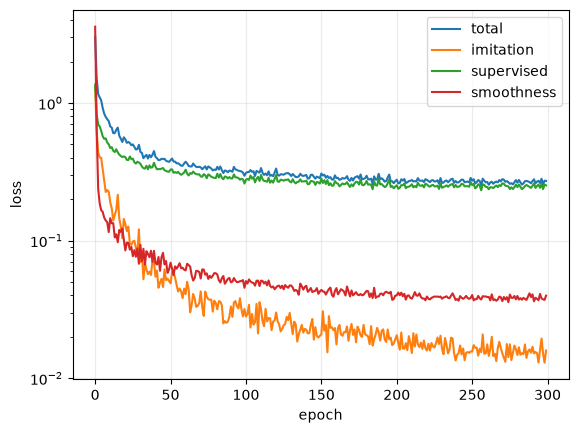

best student checkpoint: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/runs/berkeley_ur5_distilled_conv_student.pt
best validation flow loss: 0.24697867035865784


In [121]:
saved_student = torch.load(
    student_checkpoint, map_location=DEVICE, weights_only=False
)
student.load_state_dict(saved_student['model'])

for name, values in student_history.items():
    plt.plot(values, label=name)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.yscale('log')
plt.grid(alpha=.25)
plt.legend()
save_figure(plt.gcf(), '08_student_training_curves.png')
plt.show()

print('best student checkpoint:', student_checkpoint)
print('best validation flow loss:', saved_student['best_val'])

## 11. Compare experts, ensemble, and student

The wrapper below makes the ensemble look like an ordinary PyTorch model. That lets the same sampling and evaluation functions accept a single teacher, the full ensemble, or the student.

In [122]:
class EnsembleFlow(nn.Module):
    def __init__(self, members, weights):
        super().__init__()
        self.members = nn.ModuleDict(members)
        self.weights = weights

    def forward(self, t, x, start, goal, task):
        return sum(
            self.weights[name] * member(t, x, start, goal, task)
            for name, member in self.members.items()
        )


ensemble_model = EnsembleFlow(teachers, teacher_weights).to(DEVICE)

### 11.1 Sample from shared initial noise

Euler integration starts at flow time zero with a noise trajectory and repeatedly adds the predicted velocity. Passing the same noise to two models creates a fair paired comparison: differences then come from their learned fields rather than different random starts.

In [123]:
@torch.no_grad()
def sample_from_noise(
    network, start, goal, task, noise, ode_steps=ODE_STEPS
):
    network.eval()
    x = noise.clone()
    dt = 1.0 / ode_steps

    for step in range(ode_steps):
        t = torch.full((len(x),), step * dt, device=x.device)
        x = x + dt * network(t, x, start, goal, task)

    return decode_residual(x, start, goal)

### 11.2 Rollout-level quality metrics

`rollout_rmse` compares generated normalized trajectories with held-out demonstrations. Because generation is stochastic and a task can have multiple valid paths, it is a diagnostic rather than a complete success metric. `acceleration_rms` measures discrete roughness; lower is smoother, but an unrealistically straight path can also score well.

In [124]:
@torch.no_grad()
def rollout_metrics(network, loader, max_batches=4, ode_steps=50):
    squared_error = []
    acceleration = []
    generator = torch.Generator(device=DEVICE).manual_seed(SEED + 1)

    for batch_index, (trajectory, task) in enumerate(loader):
        if batch_index >= max_batches:
            break
        trajectory = trajectory.to(DEVICE)
        task = task.to(DEVICE)
        noise = torch.randn(
            residual_target(trajectory).shape,
            generator=generator,
            device=DEVICE,
        )
        generated = sample_from_noise(
            network, trajectory[:, 0], trajectory[:, -1],
            task, noise, ode_steps,
        )
        squared_error.append((generated - trajectory).square().mean().item())
        second_difference = (
            generated[:, 2:]
            - 2 * generated[:, 1:-1]
            + generated[:, :-2]
        )
        acceleration.append(
            second_difference.square().mean().sqrt().item()
        )

    return {
        'rollout_rmse': float(np.sqrt(np.mean(squared_error))),
        'acceleration_rms': float(np.mean(acceleration)),
    }

### 11.3 Measure single-example inference latency

The first five calls warm up kernels and caches. CUDA synchronization is required because GPU operations are asynchronous; without it, the timer would mostly measure dispatch time. Results depend on hardware and should be remeasured on the deployment device.

In [125]:
def latency_ms(network, example, repeats=30):
    import time

    trajectory, task = example
    trajectory = trajectory[None].to(DEVICE)
    task = task[None].to(DEVICE)
    x = torch.randn_like(residual_target(trajectory))
    t = torch.tensor([0.5], device=DEVICE)

    with torch.no_grad():
        for _ in range(5):
            network(t, x, trajectory[:, 0], trajectory[:, -1], task)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        started = time.perf_counter()
        for _ in range(repeats):
            network(t, x, trajectory[:, 0], trajectory[:, -1], task)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

    return 1000 * (time.perf_counter() - started) / repeats

### 11.4 Build the comparison table

No single column determines the winner. The ensemble often improves accuracy but calls three networks. The student should reduce parameters and latency, potentially with a modest quality cost. Validation flow MSE evaluates local vector predictions; rollout RMSE exposes accumulated integration error.

In [126]:
models_to_compare = {
    **teachers,
    'ensemble': ensemble_model,
    'student': student,
}

rows = []
for name, network in models_to_compare.items():
    rows.append({
        'model': name,
        'parameters': parameter_count(network),
        'validation_flow_mse': evaluate_flow(network, val_loader),
        **rollout_metrics(network, val_loader),
        'latency_ms': latency_ms(network, val_data[0]),
    })

comparison = pd.DataFrame(rows).set_index('model')
comparison = comparison.sort_values('validation_flow_mse')
comparison.to_csv(RESULTS_DIR / '10_model_comparison.csv')
print('saved:', RESULTS_DIR / '10_model_comparison.csv')
display(comparison.style.format({
    'parameters': '{:,.0f}',
    'validation_flow_mse': '{:.5f}',
    'rollout_rmse': '{:.4f}',
    'acceleration_rms': '{:.4f}',
    'latency_ms': '{:.3f}',
}))

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/10_model_comparison.csv


,parameters,validation_flow_mse,rollout_rmse,acceleration_rms,latency_ms
model,,,,,
latency,"905,672",0.29846,0.5668,0.2635,0.706
ensemble,"3,622,688",0.29974,0.5593,0.2474,2.871
validation,"905,672",0.30387,0.5651,0.2650,0.708
rmse,"905,672",0.30406,0.5594,0.2656,0.726
acceleration,"905,672",0.31533,0.5692,0.2335,0.706
student,"905,672",0.31862,0.5571,0.2401,0.713


### 11.5 Visualize a paired ensemble–student rollout

Both models below start from the same noise, endpoints, and task. The black dashed line is the held-out demonstration, green is the full teacher ensemble, and orange is its compact student. The plot remains in normalized units so channels with large physical ranges do not dominate visually.

In [127]:
example, example_task = val_data[0]
start = example[0][None].to(DEVICE)
goal = example[-1][None].to(DEVICE)
task = example_task[None].to(DEVICE)

generator = torch.Generator(device=DEVICE).manual_seed(SEED + 2)
shared_noise = torch.randn(
    1, TRAJECTORY_STEPS-2, state_dim,
    device=DEVICE, generator=generator,
)
ensemble_path = sample_from_noise(
    ensemble_model, start, goal, task, shared_noise
)[0].cpu().numpy()
student_path = sample_from_noise(
    student, start, goal, task, shared_noise
)[0].cpu().numpy()
real_path = example.numpy()

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/09_ensemble_student_rollout.png


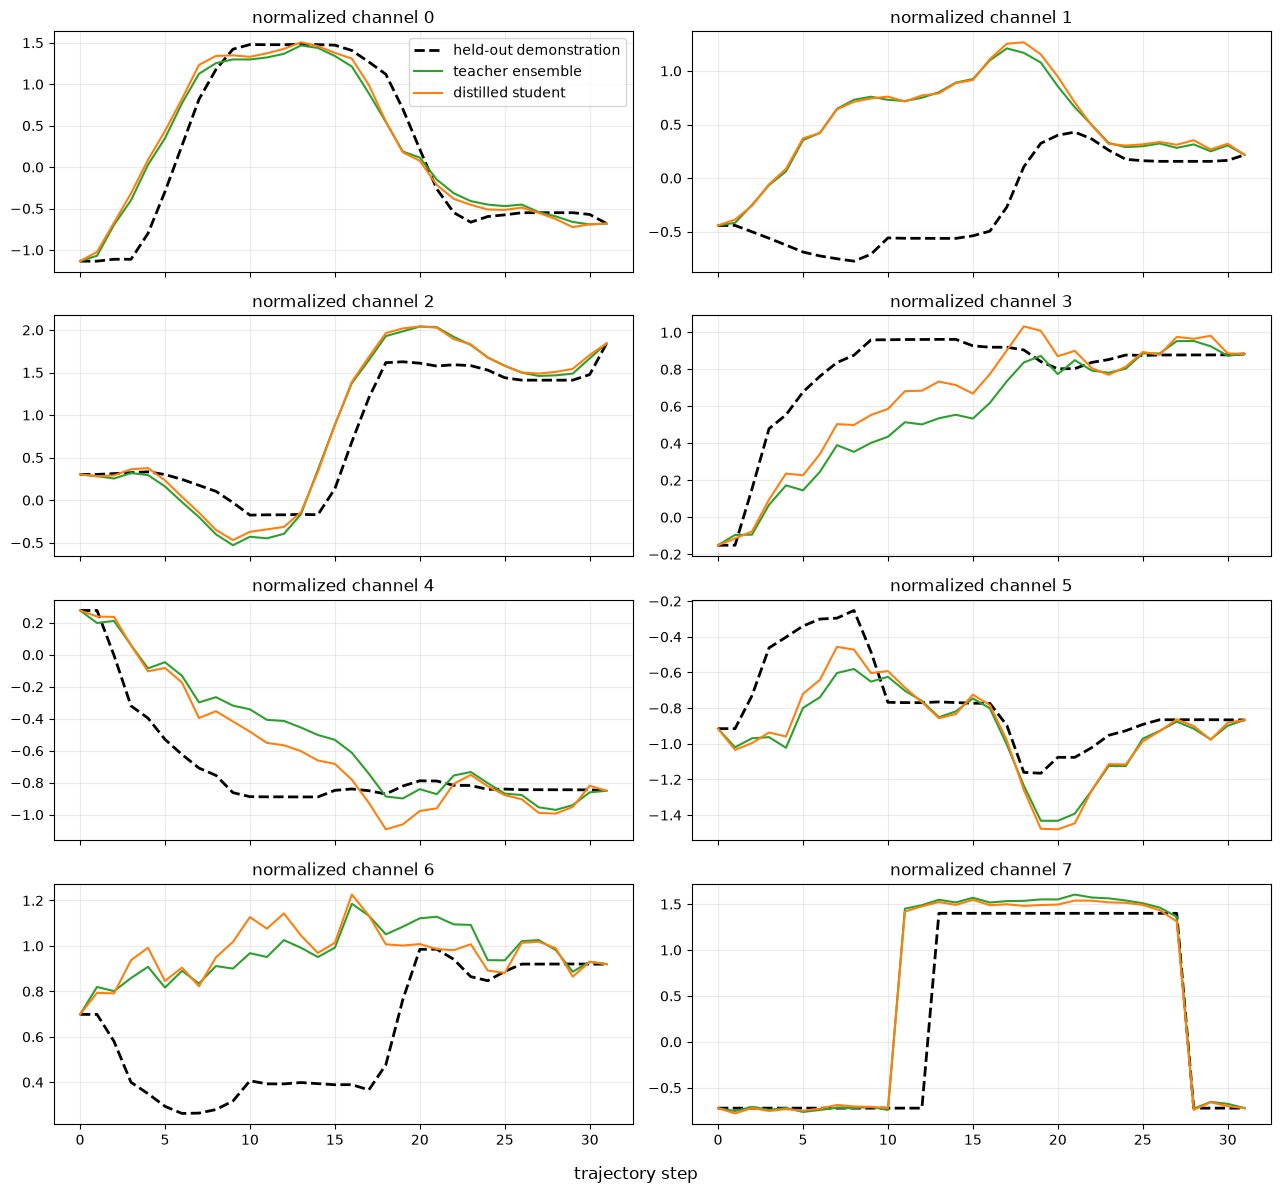

In [128]:
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(real_path[:, channel], 'k--', linewidth=2,
            label='held-out demonstration')
    ax.plot(ensemble_path[:, channel], color='tab:green',
            label='teacher ensemble')
    ax.plot(student_path[:, channel], color='tab:orange',
            label='distilled student')
    ax.set_title(f'normalized channel {channel}')
    ax.grid(alpha=.25)

axes[0, 0].legend()
fig.supxlabel('trajectory step')
fig.tight_layout()
save_figure(fig, '09_ensemble_student_rollout.png')
plt.show()

### 11.6 Quantitative held-out comparison

The next cell compares the teacher ensemble, longer-trained student, and straight interpolation using shared initial noise. RMSE, endpoint error, acceleration, jerk, and predictive variance are measured in the original recorded state units. **Collision-free rate is unavailable:** this Berkeley table contains states and task labels but no obstacle poses, collision meshes, or simulator contacts. Reporting a numeric collision rate from these data would be misleading.

In [129]:
# Draw several paired rollouts for the same held-out condition.
EVALUATION_SAMPLES = 8
generator = torch.Generator(device=DEVICE).manual_seed(SEED + 3)
evaluation_noise = torch.randn(
    EVALUATION_SAMPLES, TRAJECTORY_STEPS-2, state_dim,
    device=DEVICE, generator=generator,
)
eval_start = start.repeat(EVALUATION_SAMPLES, 1)
eval_goal = goal.repeat(EVALUATION_SAMPLES, 1)
eval_task = task.repeat(EVALUATION_SAMPLES, 1)

teacher_samples = sample_from_noise(
    ensemble_model, eval_start, eval_goal, eval_task, evaluation_noise
).cpu().numpy()
student_samples = sample_from_noise(
    student, eval_start, eval_goal, eval_task, evaluation_noise
).cpu().numpy()
s = np.linspace(0, 1, TRAJECTORY_STEPS, dtype=np.float32)[None, :, None]
interpolation = (1-s) * example.numpy()[None, :1] + s * example.numpy()[None, -1:]

# Convert normalized network values back to recorded units before scoring.
def to_recorded_units(paths):
    return paths * state_std[None, None] + state_mean[None, None]

teacher_samples_real = to_recorded_units(teacher_samples)
student_samples_real = to_recorded_units(student_samples)
interpolation_real = to_recorded_units(interpolation)
heldout_real = example.numpy() * state_std[None] + state_mean[None]

def heldout_metrics(paths, demonstration):
    error = paths - demonstration[None]
    endpoints = error[:, [0, -1]]
    acceleration = np.diff(paths, n=2, axis=1)
    jerk = np.diff(paths, n=3, axis=1)
    return {
        'collision_free_rate': np.nan,
        'endpoint_rmse': np.sqrt(np.mean(endpoints**2)),
        'demo_rmse': np.sqrt(np.mean(error**2)),
        'acceleration_rms': np.sqrt(np.mean(acceleration**2)),
        'jerk_rms': np.sqrt(np.mean(jerk**2)),
        'ensemble_variance': np.var(paths, axis=0).mean() if len(paths) > 1 else 0.0,
    }

heldout_rows = []
for name, paths in [
    ('teacher ensemble', teacher_samples_real),
    ('student', student_samples_real),
    ('interpolation', interpolation_real),
]:
    heldout_rows.append({'model': name, **heldout_metrics(paths, heldout_real)})

heldout_comparison = pd.DataFrame(heldout_rows).set_index('model')
heldout_comparison.to_csv(RESULTS_DIR / '11_heldout_comparison.csv')
print('saved:', RESULTS_DIR / '11_heldout_comparison.csv')
display(heldout_comparison.style.format({
    'collision_free_rate': lambda value: 'N/A — no scene geometry' if pd.isna(value) else f'{value:.1%}',
    'endpoint_rmse': '{:.8f}',
    'demo_rmse': '{:.5f}',
    'acceleration_rms': '{:.5f}',
    'jerk_rms': '{:.5f}',
    'ensemble_variance': '{:.6f}',
}))

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/11_heldout_comparison.csv


,collision_free_rate,endpoint_rmse,demo_rmse,acceleration_rms,jerk_rms,ensemble_variance
model,,,,,,
teacher ensemble,N/A — no scene geometry,0.00000000,0.09188,0.10308,0.17883,0.003387
student,N/A — no scene geometry,0.00000000,0.08715,0.10920,0.19070,0.003204
interpolation,N/A — no scene geometry,0.00000000,0.24705,0.00000,0.00000,0.000000


### 11.7 Separate 3D teacher and student demonstrations

These interactive figures use the pose-channel and coordinate-frame assumptions declared in Section 7. Each figure overlays the held-out tool path in black. Run the IK validation cells in Section 7 before treating the reconstruction as robot geometry.

In [130]:
def tool_positions(states):
    return np.stack([state_to_target_pose(state)[:3, 3] for state in states])

def trajectory_figure_3d(samples, demonstration, title, color):
    figure = go.Figure()
    real_xyz = tool_positions(demonstration)
    figure.add_trace(go.Scatter3d(
        x=real_xyz[:, 0], y=real_xyz[:, 1], z=real_xyz[:, 2],
        mode='lines+markers', name='held-out demonstration',
        line=dict(color='black', width=6, dash='dash'), marker=dict(size=3),
    ))
    for index, sample_path in enumerate(samples):
        xyz = tool_positions(sample_path)
        figure.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode='lines',
            name=f'sample {index+1}', legendgroup='generated',
            showlegend=index == 0, line=dict(color=color, width=4), opacity=.55,
        ))
    figure.update_layout(
        title=title, width=850, height=650,
        scene=dict(xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
                   aspectmode='data'),
    )
    return figure

teacher_figure_3d = trajectory_figure_3d(
    teacher_samples_real, heldout_real,
    'Teacher ensemble — 3D held-out demonstration', '#2ca02c',
)
student_figure_3d = trajectory_figure_3d(
    student_samples_real, heldout_real,
    'Longer-trained student — 3D held-out demonstration', '#ff7f0e',
)
teacher_html = RESULTS_DIR / '12_teacher_3d.html'
student_html = RESULTS_DIR / '13_student_3d.html'
teacher_figure_3d.write_html(teacher_html, include_plotlyjs='cdn')
student_figure_3d.write_html(student_html, include_plotlyjs='cdn')
print('saved:', teacher_html)
print('saved:', student_html)
# PNG export uses Plotly's optional Kaleido package; HTML is always saved.
try:
    teacher_figure_3d.write_image(RESULTS_DIR / '12_teacher_3d.png', scale=2)
    student_figure_3d.write_image(RESULTS_DIR / '13_student_3d.png', scale=2)
    print('saved static teacher/student 3D PNGs')
except Exception as error:
    print('PNG export skipped; install kaleido to enable it:', error)
teacher_figure_3d.show()
student_figure_3d.show()

saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/12_teacher_3d.html
saved: /nfs/asmfsnobackup1/asmnobackup/user/abdess_o/Projects/Robot_Direction_Estimation/Results/13_student_3d.html
PNG export skipped; install kaleido to enable it: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

